In [1]:
from IPython.display import HTML
HTML("<style>.container{width:100%!important;margin:auto}div.cell,div.input_area{padding:2px;margin:0}div.output_wrapper{padding:0;margin:0}</style>")

In [2]:
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, precision_recall_fscore_support

In [3]:
# --- 1. DATA PREPARATION ---
import numpy as np
## load Data
data = load_iris()
#print(data)

X_raw = torch.tensor(data.data, dtype = torch.float32)
Y_raw = torch.tensor(data.target, dtype = torch.long) ##long is integer

print(X_raw.shape, Y_raw.shape)

#print(Y_raw)
#print(X_raw)

print(np.unique(Y_raw))

X_train, X_test, Y_train, Y_test = train_test_split(X_raw, Y_raw, test_size = 0.2, random_state=42)
#validation
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size = 0.1, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)

scaler = StandardScaler()
## normalize using X_train
X_train = torch.tensor(scaler.fit_transform(X_train), dtype = torch.float32)
X_val = torch.tensor(scaler.transform(X_val), dtype = torch.float32)
X_test = torch.tensor(scaler.transform(X_test), dtype = torch.float32)



torch.Size([150, 4]) torch.Size([150])
[0 1 2]
torch.Size([108, 4]) torch.Size([12, 4]) torch.Size([30, 4])


In [4]:
# --- 2. CREATE PYTORCH DATASETS & DATALOADERS ---

train_dataset = TensorDataset(X_train, Y_train)
val_dataset = TensorDataset(X_val, Y_val)
test_dataset = TensorDataset(X_test, Y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

In [5]:
# --- 3. DEFINE THE MLP ---
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SimpleMLP, self).__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.hidden(x)) ## sending x to hidden 
        x = self.output(x)
        return x # return prediction


In [6]:
# --- 4. TRAINING SETUP ---

model = SimpleMLP(input_dim = X_train.shape[1], hidden_dim = 8, output_dim = len(np.unique(Y_raw)))
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr = 0.01 )

print("Training started")
MAX_EPOCHS = 1000
for epoch in range(1, MAX_EPOCHS+1):
    model.train()
    train_loss = 0
    accuracy = 0

    for batch_X, batch_Y in train_loader:
        optimizer.zero_grad()
        pred = model(batch_X)
        loss = criterion(pred, batch_Y)
        loss.backward()
        optimizer.step()

        train_loss = train_loss + loss.item()*batch_X.size(0)
        train_pred = pred.argmax(dim = 1)
        accuracy = accuracy + (train_pred==batch_Y).sum().item()


    avg_loss = train_loss/len(train_loader.dataset)
    avg_acc = accuracy/len(train_loader.dataset)*100


    ## validation
    model.eval()
    val_loss = 0
    val_acc = 0

    with torch.no_grad():
        for batch_X, batch_Y in val_loader:
            pred = model(batch_X)
            loss = criterion(pred, batch_Y)

            val_loss = val_loss + loss.item()*batch_X.size(0)
            val_pred = pred.argmax(dim = 1)
            val_acc = val_acc + (val_pred==batch_Y).sum().item()


    avg_loss_val = val_loss/len(val_loader.dataset)
    avg_acc_val = val_acc/len(val_loader.dataset)*100

    print(f"Epoch {epoch}-->Loss: {avg_loss} &------> Accuracy: {avg_acc} || ValLoss: {avg_loss_val} & ValAccuracy: {avg_acc_val}")

Training started
Epoch 1-->Loss: 1.0189342300097148 &------> Accuracy: 43.51851851851852 || ValLoss: 1.0105412006378174 & ValAccuracy: 41.66666666666667
Epoch 2-->Loss: 0.9810358705344023 &------> Accuracy: 41.66666666666667 || ValLoss: 0.9850135445594788 & ValAccuracy: 58.333333333333336
Epoch 3-->Loss: 0.9484495697198091 &------> Accuracy: 63.888888888888886 || ValLoss: 0.9627845883369446 & ValAccuracy: 58.333333333333336
Epoch 4-->Loss: 0.9204603102472093 &------> Accuracy: 70.37037037037037 || ValLoss: 0.9432433247566223 & ValAccuracy: 58.333333333333336
Epoch 5-->Loss: 0.8961454033851624 &------> Accuracy: 68.51851851851852 || ValLoss: 0.9258819222450256 & ValAccuracy: 58.333333333333336
Epoch 6-->Loss: 0.874569332158124 &------> Accuracy: 65.74074074074075 || ValLoss: 0.9103696942329407 & ValAccuracy: 58.333333333333336
Epoch 7-->Loss: 0.8556859581558792 &------> Accuracy: 66.66666666666666 || ValLoss: 0.8962504863739014 & ValAccuracy: 58.333333333333336
Epoch 8-->Loss: 0.8383487

In [7]:
# --- 5. EVALUATION ---
model.eval()
test_acc = 0
all_preds = []
all_target = []

with torch.no_grad():
    for batch_X, batch_Y in val_loader:
        pred = model(batch_X)
        test_pred = pred.argmax(dim = 1)
        all_preds.extend(test_pred.cpu().numpy())
        all_target.extend(batch_Y.cpu().numpy())

target_name = data.target_names

print(classification_report(all_target, all_preds, target_names = target_name))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         3
  versicolor       1.00      0.60      0.75         5
   virginica       0.67      1.00      0.80         4

    accuracy                           0.83        12
   macro avg       0.89      0.87      0.85        12
weighted avg       0.89      0.83      0.83        12



In [13]:
# D. Early Stopping & Checkpointing Setup (Copy 4)
import copy
model = SimpleMLP(input_dim = X_train.shape[1], hidden_dim = 8, output_dim = len(np.unique(Y_raw)))
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr = 0.01 )
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = "min", factor = 0.5, patience = 5)

print("Training started")
MAX_EPOCHS = 1000
PATIENCE = 15
pateince_counter = 0
best_val_loss = float("inf")
best_mode_weights = None
for epoch in range(1, MAX_EPOCHS+1):
    model.train()
    train_loss = 0
    accuracy = 0

    for batch_X, batch_Y in train_loader:
        optimizer.zero_grad()
        pred = model(batch_X)
        loss = criterion(pred, batch_Y)
        loss.backward()
        optimizer.step()

        train_loss = train_loss + loss.item()*batch_X.size(0)
        train_pred = pred.argmax(dim = 1)
        accuracy = accuracy + (train_pred==batch_Y).sum().item()


    avg_loss = train_loss/len(train_loader.dataset)
    avg_acc = accuracy/len(train_loader.dataset)*100


    ## validation
    model.eval()
    val_loss = 0
    val_acc = 0

    with torch.no_grad():
        for batch_X, batch_Y in val_loader:
            pred = model(batch_X)
            loss = criterion(pred, batch_Y)

            val_loss = val_loss + loss.item()*batch_X.size(0)
            val_pred = pred.argmax(dim = 1)
            val_acc = val_acc + (val_pred==batch_Y).sum().item()

    
        avg_loss_val = val_loss/len(val_loader.dataset)
        avg_acc_val = val_acc/len(val_loader.dataset)*100
    scheduler.step(avg_loss_val)    
    if avg_loss_val<best_val_loss:
        best_val_loss = avg_loss_val
        best_mode_weights = copy.deepcopy(model.state_dict())
        patience_ocunter = 0
    else:
        pateince_counter = pateince_counter + 1
    if pateince_counter >=PATIENCE:
        break
    print(f"Epoch {epoch}-->Loss: {avg_loss} &------> Accuracy: {avg_acc} || ValLoss: {avg_loss_val} & ValAccuracy: {avg_acc_val}")

Training started
Epoch 1-->Loss: 1.210353551087556 &------> Accuracy: 1.8518518518518516 || ValLoss: 1.1856913566589355 & ValAccuracy: 0.0
Epoch 2-->Loss: 1.1925740904278226 &------> Accuracy: 1.8518518518518516 || ValLoss: 1.171739101409912 & ValAccuracy: 0.0
Epoch 3-->Loss: 1.1763843474564728 &------> Accuracy: 5.555555555555555 || ValLoss: 1.1586377620697021 & ValAccuracy: 8.333333333333332
Epoch 4-->Loss: 1.1613737300590232 &------> Accuracy: 9.25925925925926 || ValLoss: 1.1465660333633423 & ValAccuracy: 8.333333333333332
Epoch 5-->Loss: 1.147605467725683 &------> Accuracy: 11.11111111111111 || ValLoss: 1.1347978115081787 & ValAccuracy: 16.666666666666664
Epoch 6-->Loss: 1.1343879169887967 &------> Accuracy: 17.59259259259259 || ValLoss: 1.1239913702011108 & ValAccuracy: 25.0
Epoch 7-->Loss: 1.121719514882123 &------> Accuracy: 25.925925925925924 || ValLoss: 1.1136491298675537 & ValAccuracy: 25.0
Epoch 8-->Loss: 1.1099927778597232 &------> Accuracy: 31.48148148148148 || ValLoss: 1.

In [14]:
# --- 5. EVALUATION --- (Copy 5)

model.eval()
test_acc = 0
all_preds = []
all_target = []

with torch.no_grad():
    for batch_X, batch_Y in val_loader:
        pred = model(batch_X)
        test_pred = pred.argmax(dim = 1)
        all_preds.extend(test_pred.cpu().numpy())
        all_target.extend(batch_Y.cpu().numpy())

target_name = data.target_names

print(classification_report(all_target, all_preds, target_names = target_name))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         3
  versicolor       1.00      0.80      0.89         5
   virginica       0.80      1.00      0.89         4

    accuracy                           0.92        12
   macro avg       0.93      0.93      0.93        12
weighted avg       0.93      0.92      0.92        12



[0.19258384 0.15255302 0.13543138 0.36998037]
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


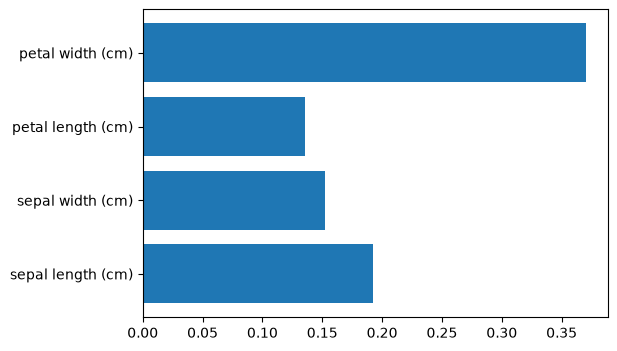

In [16]:
# --- Feature Importance via Input Gradient Analysis ---
import matplotlib.pyplot as plt

X_test_grad = X_test.clone().detach().requires_grad_(True)

output = model(X_test_grad)
output.sum().backward()
importance = X_test_grad.grad.abs().mean(dim=0).numpy()
print(importance)
feature_names = data.feature_names
print(feature_names)

plt.figure(figsize = (6,4))
plt.barh(feature_names, importance)
plt.show()

In [ ]:
# Train on some other standard datasets
from sklearn.datasets import load_wine, load_digits, load_breast_cancer
import numpy as np
# Copy 1, 2, 3, D, 5

# --- 1. DATA PREPARATION ---
import numpy as np
## load Data
data = load_digits()
#print(data)

X_raw = torch.tensor(data.data, dtype = torch.float32)
Y_raw = torch.tensor(data.target, dtype = torch.long) ##long is integer

print(X_raw.shape, Y_raw.shape)

#print(Y_raw)
#print(X_raw)

print(np.unique(Y_raw))

X_train, X_test, Y_train, Y_test = train_test_split(X_raw, Y_raw, test_size = 0.2, random_state=42)
#validation
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size = 0.1, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)

scaler = StandardScaler()
## normalize using X_train
X_train = torch.tensor(scaler.fit_transform(X_train), dtype = torch.float32)
X_val = torch.tensor(scaler.transform(X_val), dtype = torch.float32)
X_test = torch.tensor(scaler.transform(X_test), dtype = torch.float32)

train_dataset = TensorDataset(X_train, Y_train)
val_dataset = TensorDataset(X_val, Y_val)
test_dataset = TensorDataset(X_test, Y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

# --- 3. DEFINE THE MLP ---
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SimpleMLP, self).__init__()
        self.hidden1 = nn.Linear(input_dim, hidden_dim)
        self.hidden2 = nn.Linear(hidden_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, output_dim)
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()

    
    def forward(self, x):
        x = self.relu1(self.hidden1(x)) ## sending x to hidden 
        x = self.relu2(self.hidden2(x))
        x = self.output(x)
        return x # return prediction


import copy
model = SimpleMLP(input_dim = X_train.shape[1], hidden_dim = 8, output_dim = len(np.unique(Y_raw)))
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr = 0.01 )
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = "min", factor = 0.5, patience = 5)

print("Training started")
MAX_EPOCHS = 1000
PATIENCE = 15
pateince_counter = 0
best_val_loss = float("inf")
best_mode_weights = None
for epoch in range(1, MAX_EPOCHS+1):
    model.train()
    train_loss = 0
    accuracy = 0

    for batch_X, batch_Y in train_loader:
        optimizer.zero_grad()
        pred = model(batch_X)
        loss = criterion(pred, batch_Y)
        loss.backward()
        optimizer.step()

        train_loss = train_loss + loss.item()*batch_X.size(0)
        train_pred = pred.argmax(dim = 1)
        accuracy = accuracy + (train_pred==batch_Y).sum().item()


    avg_loss = train_loss/len(train_loader.dataset)
    avg_acc = accuracy/len(train_loader.dataset)*100


    ## validation
    model.eval()
    val_loss = 0
    val_acc = 0

    with torch.no_grad():
        for batch_X, batch_Y in val_loader:
            pred = model(batch_X)
            loss = criterion(pred, batch_Y)

            val_loss = val_loss + loss.item()*batch_X.size(0)
            val_pred = pred.argmax(dim = 1)
            val_acc = val_acc + (val_pred==batch_Y).sum().item()

    
        avg_loss_val = val_loss/len(val_loader.dataset)
        avg_acc_val = val_acc/len(val_loader.dataset)*100
    scheduler.step(avg_loss_val)    
    if avg_loss_val<best_val_loss:
        best_val_loss = avg_loss_val
        best_mode_weights = copy.deepcopy(model.state_dict())
        patience_ocunter = 0
    else:
        pateince_counter = pateince_counter + 1
    if pateince_counter >=PATIENCE:
        break
    print(f"Epoch {epoch}-->Loss: {avg_loss} &------> Accuracy: {avg_acc} || ValLoss: {avg_loss_val} & ValAccuracy: {avg_acc_val}")


    # --- 5. EVALUATION --- (Copy 5)

model.eval()
test_acc = 0
all_preds = []
all_target = []

with torch.no_grad():
    for batch_X, batch_Y in val_loader:
        pred = model(batch_X)
        test_pred = pred.argmax(dim = 1)
        all_preds.extend(test_pred.cpu().numpy())
        all_target.extend(batch_Y.cpu().numpy())

target_name = data.target_names


torch.Size([1797, 64]) torch.Size([1797])
[0 1 2 3 4 5 6 7 8 9]
torch.Size([1293, 64]) torch.Size([144, 64]) torch.Size([360, 64])
Training started
Epoch 1-->Loss: 2.33373399179109 &------> Accuracy: 9.048723897911833 || ValLoss: 2.3131395181020102 & ValAccuracy: 13.194444444444445
Epoch 2-->Loss: 2.313484812004107 &------> Accuracy: 11.1368909512761 || ValLoss: 2.29608334435357 & ValAccuracy: 14.583333333333334
Epoch 3-->Loss: 2.2975316860836235 &------> Accuracy: 11.755607115235886 || ValLoss: 2.281918446222941 & ValAccuracy: 15.972222222222221
Epoch 4-->Loss: 2.282262829782791 &------> Accuracy: 12.606341840680587 || ValLoss: 2.2671634356180825 & ValAccuracy: 18.75
Epoch 5-->Loss: 2.2655529398744823 &------> Accuracy: 13.9984532095901 || ValLoss: 2.2498221662309437 & ValAccuracy: 15.972222222222221
Epoch 6-->Loss: 2.245536284767558 &------> Accuracy: 14.30781129156999 || ValLoss: 2.2282085683610706 & ValAccuracy: 15.972222222222221
Epoch 7-->Loss: 2.219478417438587 &------> Accuracy